# Maximum Independent Set using QAOA

## Problem statement
Given an undirected graph $G = (V, E)$ with $n$ vertices in $V$ and $m$ edges in $E$, what is the maximum number of nodes should be choosen such that the choosen nodes are not neighbor to each other?

## Demonstrating the graph

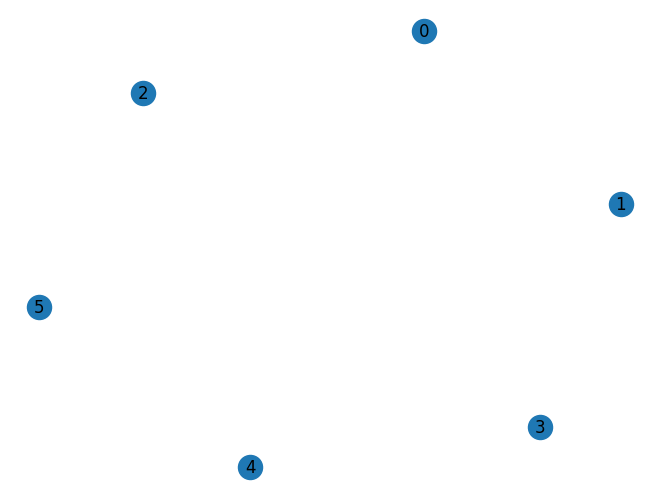

In [1]:
import numpy as np
import rustworkx as rx
from rustworkx.visualization import mpl_draw

default_color = "#1f78b4"
mark_color = "red"

# n, m = map(int, input().split())
# edges = [(x1 - 1, x2 - 1) for x1, x2 in (map(int, input().split()) for _ in range(m))]

n = 6
m = 0
edges = [

]

G = rx.PyGraph()
G.add_nodes_from(range(n))
for x1, x2 in edges:
    G.add_edge(x1, x2, None)

mpl_draw(G, with_labels=True, label=list(range(n)))


## Representing the problem with QUBO model
Define set $M$ is the maximum independent set of $G = (V, E)$. We also define $x_i$ where vertex $i \in V$ as:

$$
\displaystyle 
\begin{cases}
x_i = 1, i \in M \\
x_i = 0, i \notin M
\end{cases}
$$

In other words, if we choose vertex $i$ to be in set M, then we have count it 1. This means for MIS problem, we want to maximize:

$$\displaystyle \sum_{i \in V}^{}x_i $$

Which is equivalent to minimizing (we will be using this formula instead):

$$\displaystyle -\sum_{i \in V}^{}x_i $$

This function $f(x)$, however, need to be constrained to:

$$x_i + x_j \leq 1$$

The constraint above means for every edge $(i, j) \in E$, we want to make sure $i$ and $j$ are not picked in $M$ simultaneously. To enforce this constraint to our minimized formula, we want to have a penalty portion to increase the minimized formula to detect if we satisfy the constraint after finding MIS:

$$\displaystyle P\sum_{(i, j) \in E}^{}x_i x_j$$

Our final QUBO model for MIS problem would then be:

$$\displaystyle f_{QUBO}(x) = -\sum_{i \in V}^{}x_i + P\sum_{(i, j) \in E}^{}x_i x_j$$

$P$ is the amplitude of penalty we want to choose for a specific problem. Usually, it would be the expected optimal solution to the problem. The reason we want to adjust it is because in QAOA, the more we scale this constant $P$, the more exhausted the machine might suffers. In this MIS problem, the optimal choice we can pick for $P$ is the number of vertices $V$ we have in $G$. 

For that reason, if $P = n$, and somehow in our solution we have an invalid pair of vertices $i$ and $j$, we increase $f_{QUBO}$ such that $f_{QUBO} \ge 0$. Vice versa, if there is no invalid pair of vertices $i$ and $j$, we have $f_{QUBO} \lt 0$. Hence, we can detect whether our solution has penalty or not.

We can express the Maximum Independent Set (MIS) problem in QUBO form as

$$
f_{\text{QUBO}}(x) = x^T Q x
$$

where the binary decision vector is

$$
x =
\begin{bmatrix}
x_0 \\
x_1 \\
\vdots \\
x_{n-1}
\end{bmatrix},
\quad
x_i \in \{0,1\}.
$$

The QUBO matrix $Q \in \mathbb{R}^{n \times n}$ is defined as

$$
Q =
\begin{bmatrix}
-1 & \frac{P}{2} e_{(0,1)} & \frac{P}{2} e_{(0,2)} & \cdots & \frac{P}{2} e_{(0,n-1)} \\
\frac{P}{2} e_{(1,0)} & -1 & \frac{P}{2} e_{(1,2)} & \cdots & \frac{P}{2} e_{(1,n-1)} \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
\frac{P}{2} e_{(n-1,0)} & \frac{P}{2} e_{(n-1,1)} & \cdots & \cdots & -1
\end{bmatrix},
$$

where $P > 0$ is the penalty parameter and

$$
e_{(i,j)} =
\begin{cases}
1 & \text{if } (i,j) \in E, \\
0 & \text{otherwise}.
\end{cases}
$$

Equivalently, if $A$ denotes the adjacency matrix of the graph $G = (V,E)$, then

$$
A_{ij} =
\begin{cases}
1 & \text{if } (i,j) \in E, \\
0 & \text{otherwise},
\end{cases}
$$

the QUBO matrix can be written compactly as

$$
Q = -I + \frac{P}{2} A,
$$

where $I$ is the identity matrix.



## Brute-forcing with QUBO formula

Maximum independent set value: [[6]]
Configuration: [1 1 1 1 1 1]


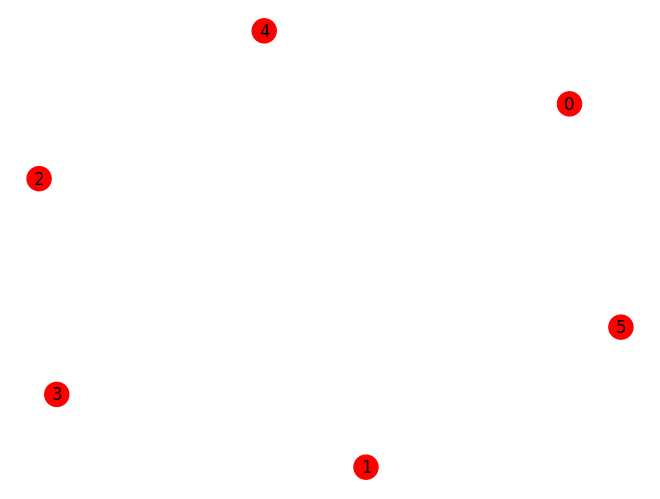

In [2]:
def qubo_maximum_independent_set(n: int, edges: list[tuple[int, int]]) -> (int, list[int]):
    penalty = n + 1

    Q = np.matrix([[0] * n] * n)

    for i in range(n):
        Q[i, i] = -1

    for i, j in edges:
        Q[i, j] = Q[j, i] = penalty

    min_val = 0
    configuration = None
    for i in range(2**n):
        x = np.array([(i >> j) & 1 for j in range(n)])
        indep_set_value = x.T @ Q @ x
        if indep_set_value < min_val:
            min_val = indep_set_value
            configuration = x

    return -min_val, configuration

max_indep_set_value, configuration = qubo_maximum_independent_set(n, edges)
print("Maximum independent set value:", max_indep_set_value)
print("Configuration:", configuration)

G2 = rx.PyGraph()
G2 = G.copy()
color = [mark_color if configuration[i] == 1 else default_color for i in range(n)]
mpl_draw(G2, with_labels=True, label=list(range(n)), node_color = color)

## Turn it into an Ising Hamiltonian

Hamiltonian system only works for $z_i \in {\{-1, 1\}}^n$ instead of $x_i \in {\{0, 1\}}^n$. Therefore, we need to convert $x_i$ into $z_i$ via:

$$z_i = \frac{1 - x_i}{2}$$

By substituting $z_i$ into $f_{QUBO}(x)$, we have: 

$$ \displaystyle f_{QUBO}(z) = \frac{1}{4}\sum_{ij}^{}Q_{ij}(1 - z_i)(1 - z_j) $$

After doing some linear algebra, we got:

$$ \displaystyle f_{QUBO}(z) = \frac{1}{4}\sum_{ij}^{}Q_{ij}z_iz_j - \frac{1}{4}\sum_{ij}^{}(Q_{ij} + Q_{ji})z_i + \frac{n^2}{4}$$

By dropping $\frac{1}{4}$ and $\frac{n^2}{4}$ (which is not important in optimization) and setting $b = \sum_{ij}^{}(Q_{ij} + Q_{ji})z_i$, we have:

$$ \displaystyle f_{QUBO}(z) =  z^TQz - b^Tz$$

## Build The Pauli Opertors

In [3]:
from qiskit.quantum_info import SparsePauliOp

def eval_cost_hamiltonian(G: rx.PyGraph, configuration: list[int]):
    n = G.num_nodes()
    P = n ** 2  # assuming P = number of nodes
    q = [-1] * n
    
    # Convert -1/1 configuration to x_i in {0,1}
    # -1 -> yes -> x_i = 1, 1 -> no -> x_i = 0
    z = configuration  # z_i = 1 if node i is in the independent set, else 0
    
    cost = 0
    # Quadratic edge term
    for i, j in G.edge_list():
        cost -= (P / 4) * z[i]
        cost -= (P / 4) * z[j]
        cost += P / 4
        cost += (P / 4) * z[i] * z[j]
    
    # Linear term
    for i in range(n):
        cost += 0.5 * q[i]
        cost -= 0.5 * q[i] * z[i]

    
    return cost

# Example usage
# config = [-1, 1, -1, 1, -1]
# cost = eval_cost_hamiltonian(G, config)
# print(f"Cost of configuration {config}:", cost)

def build_mis_paulis(G: rx.PyGraph):

    n = G.num_nodes()
    P = n ** 2  # assuming P = number of nodes
    q = [-1] * n
    pauli_list = []

    # ZZ terms (edge penalties)
    for i, j in G.edge_list():
        pauli_list.append(("ZZ", [i, j], P / 4))
        pauli_list.append(("Z", [i], -P / 4))
        pauli_list.append(("Z", [j], -P / 4))

    # Z terms (vertex rewards + edge corrections)
    for v in G.node_indices():
        pauli_list.append(("Z", [v], -0.5 * q[v]))

    return pauli_list

mis_paulis = build_mis_paulis(G)
mis_hamiltonian = SparsePauliOp.from_sparse_list(mis_paulis, n)

print("MIS Hamiltonian:", mis_hamiltonian)


MIS Hamiltonian: SparsePauliOp(['IIIIIZ', 'IIIIZI', 'IIIZII', 'IIZIII', 'IZIIII', 'ZIIIII'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])


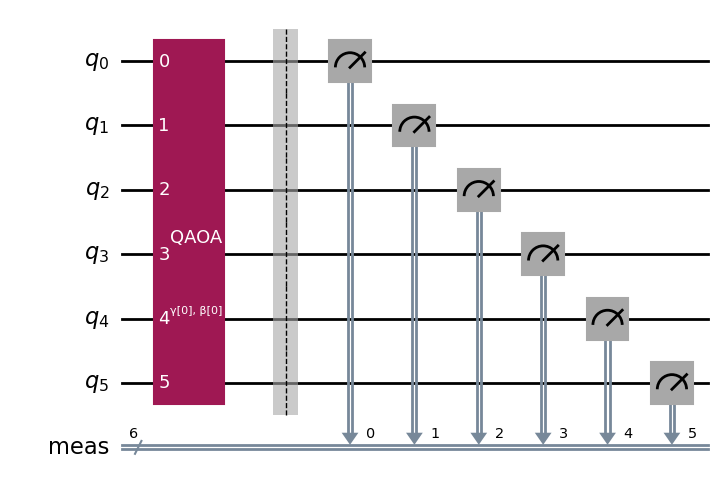

In [4]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=mis_hamiltonian, reps=1)
circuit.measure_all()

circuit.draw("mpl")
# print(circuit.parameters)


In [5]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

simulator = AerSimulator()

pm = generate_preset_pass_manager(optimization_level=3, backend=simulator)

circuit = pm.run(circuit)

# circuit.draw("mpl")

# result = simulator.run(pm, shots=1024).result().count




In [ ]:
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from matplotlib import pyplot as plt


optimizer = COBYLA()
sampler = StatevectorSampler()

qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=1
)

result = qaoa.compute_minimum_eigenvalue(mis_hamiltonian)

print(result.eigenstate)

bitstrings = list(result.eigenstate.keys())
probabilities = list(result.eigenstate.values())

bitstrings_sorted = sorted(bitstrings)  # '00001', '00010', '00100', ...
probabilities_sorted = [result.eigenstate[b] for b in bitstrings_sorted]

plt.figure(figsize=(20,5))
plt.bar(bitstrings_sorted, probabilities_sorted, color='skyblue')
plt.xlabel('Bitstring (configuration)')
plt.ylabel('Probability')
plt.title('QAOA Sampling Distribution')
plt.xticks(rotation=45)
plt.show()

/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.


### NOTE

1. Understand why P is too large can lead to optimization landscape going bad
2. QAOA Ansatz?